# Day 2 — Does Memory Help?

This notebook completes the Day 2 assignment using the **same ABUK stock, five features, chronological 70/30 split, and next-day-return target** as Day 1.

It answers two questions:

1. Does an LSTM that sees the last 10 feature rows beat the Day 1 MLP on ABUK?
2. What happens when MLP and LSTM signals are applied across the full EGX stock universe as a simple portfolio rebalancer?

The comparison uses unseen future data, a zero-return prediction baseline, and direction accuracy. The portfolio section is an educational frictionless backtest, not financial advice.

In [47]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

candidates = [Path.cwd(), *Path.cwd().parents, Path('/Users/adhamelbaz/2026-orion')]
REPO_ROOT = next((p for p in candidates if (p / 'src').exists() and (p / 'data' / 'egx').exists()), None)
if REPO_ROOT is None:
    raise FileNotFoundError('Could not locate the repository root.')
sys.path.insert(0, str(REPO_ROOT / 'src'))

from tradinglab.data_feed import DataFeed
from tradinglab.features import FEATURE_NAMES, feature_columns

SYMBOL = 'ABUK'
SEQ_LEN = 10
DATA_DIR = REPO_ROOT / 'data' / 'egx'
print(f'Repository: {REPO_ROOT}')
print(f'Experiment: {SYMBOL}, sequence length={SEQ_LEN}')

Repository: /Users/adhamelbaz/2026-orion
Experiment: ABUK, sequence length=10


## 0. Visual check — did the sine-wave shift disappear?

First we recreate yesterday's failure. The MLP receives only the current sine value and predicts the next value. Because the same value can occur while the wave is rising or falling, its safest solution resembles persistence: the prediction follows the actual curve with a one-step lag.

Then the LSTM receives the last five values. That short history reveals direction, so its prediction should follow the current curve rather than appearing shifted.

MLP one-point test MSE: 0.014017
LSTM five-point test MSE: 0.001858
LSTM error reduction: 7.5x


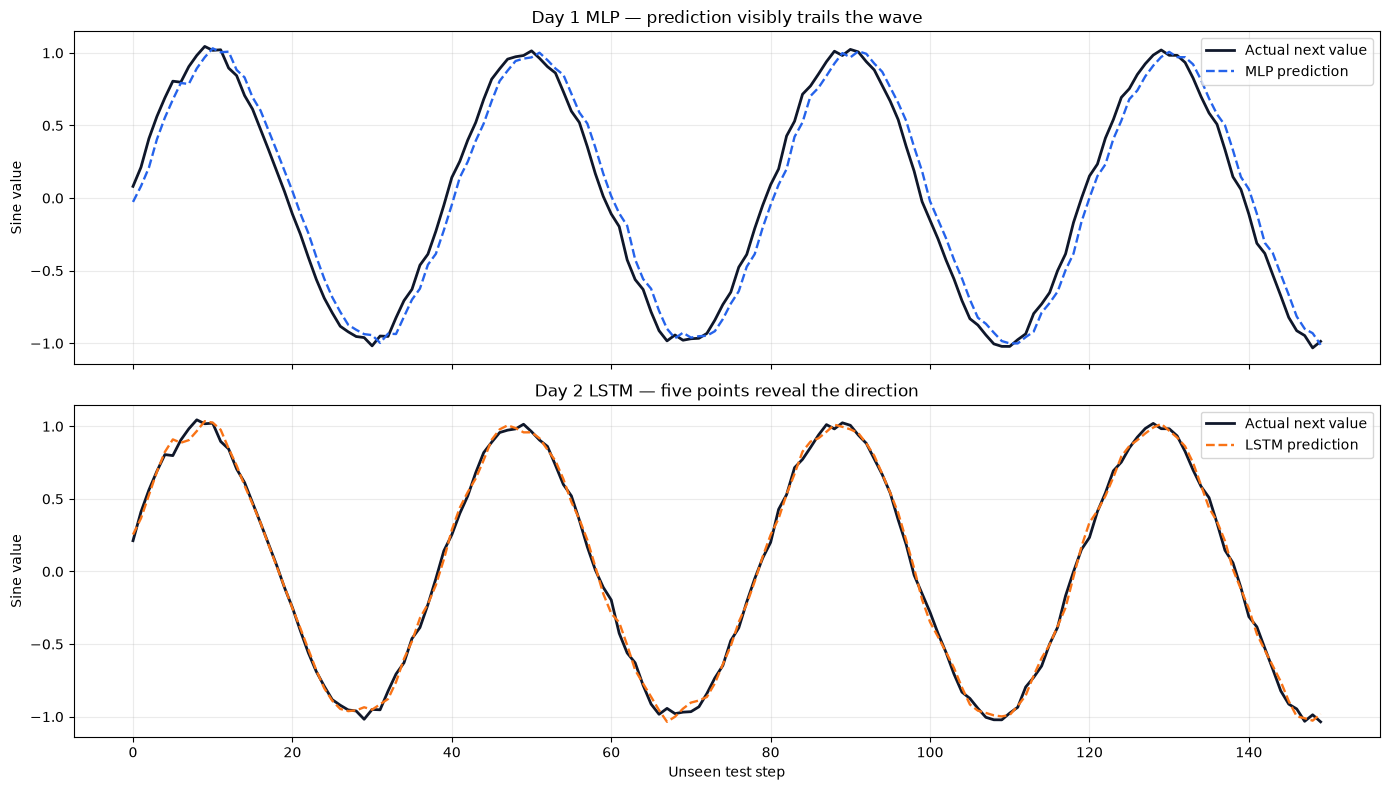

In [48]:
torch.manual_seed(0); np.random.seed(0)
t_sine = np.linspace(0, 200*np.pi, 4000)
sine = np.sin(t_sine) + 0.03*np.random.randn(len(t_sine))

# Yesterday: one point in, next point out.
X_point = sine[:-1].reshape(-1, 1).astype('float32')
y_point = sine[1:].astype('float32')
sine_cut = int(len(X_point)*.70)
Xp_tr, Xp_te = torch.tensor(X_point[:sine_cut]), torch.tensor(X_point[sine_cut:])
yp_tr, yp_te = torch.tensor(y_point[:sine_cut]), torch.tensor(y_point[sine_cut:])

class SineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

sine_mlp = SineMLP()
optimizer = torch.optim.Adam(sine_mlp.parameters(), lr=.01)
for _ in range(300):
    optimizer.zero_grad()
    loss = nn.functional.mse_loss(sine_mlp(Xp_tr), yp_tr)
    loss.backward(); optimizer.step()

# Today: five points in, next point out.
sine_seq_len = 5
X_sine_seq, y_sine_seq = [], []
for end in range(sine_seq_len-1, len(sine)-1):
    X_sine_seq.append(sine[end-sine_seq_len+1:end+1])
    y_sine_seq.append(sine[end+1])
X_sine_seq = np.asarray(X_sine_seq, dtype='float32').reshape(-1, sine_seq_len, 1)
y_sine_seq = np.asarray(y_sine_seq, dtype='float32')
sine_seq_cut = int(len(X_sine_seq)*.70)
Xs_tr = torch.tensor(X_sine_seq[:sine_seq_cut]); Xs_te = torch.tensor(X_sine_seq[sine_seq_cut:])
ys_tr = torch.tensor(y_sine_seq[:sine_seq_cut]); ys_te = torch.tensor(y_sine_seq[sine_seq_cut:])

class SineLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True)
        self.head = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1]).squeeze(-1)

torch.manual_seed(0)
sine_lstm = SineLSTM()
optimizer = torch.optim.Adam(sine_lstm.parameters(), lr=.01)
for _ in range(300):
    optimizer.zero_grad()
    loss = nn.functional.mse_loss(sine_lstm(Xs_tr), ys_tr)
    loss.backward(); optimizer.step()

sine_mlp.eval(); sine_lstm.eval()
with torch.no_grad():
    sine_mlp_pred = sine_mlp(Xp_te).numpy()
    sine_lstm_pred = sine_lstm(Xs_te).numpy()

mlp_sine_mse = np.mean((yp_te.numpy() - sine_mlp_pred)**2)
lstm_sine_mse = np.mean((ys_te.numpy() - sine_lstm_pred)**2)
print(f'MLP one-point test MSE: {mlp_sine_mse:.6f}')
print(f'LSTM five-point test MSE: {lstm_sine_mse:.6f}')
print(f'LSTM error reduction: {mlp_sine_mse/lstm_sine_mse:.1f}x')

show = 150
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)
axes[0].plot(yp_te.numpy()[:show], label='Actual next value', color='#0f172a', lw=2)
axes[0].plot(sine_mlp_pred[:show], label='MLP prediction', color='#2563eb', ls='--', lw=1.7)
axes[0].set_title('Day 1 MLP — prediction visibly trails the wave')
axes[1].plot(ys_te.numpy()[:show], label='Actual next value', color='#0f172a', lw=2)
axes[1].plot(sine_lstm_pred[:show], label='LSTM prediction', color='#f97316', ls='--', lw=1.7)
axes[1].set_title('Day 2 LSTM — five points reveal the direction')
for ax in axes:
    ax.set_ylabel('Sine value'); ax.grid(alpha=.25); ax.legend(loc='upper right')
axes[1].set_xlabel('Unseen test step')
plt.tight_layout(); plt.show()

In the first plot, compare peaks, troughs, and zero crossings: the dashed MLP line arrives slightly late. In the second, the LSTM line should nearly overlap the actual curve. This demonstrates that memory fixes the information problem on the controlled periodic signal; it does not guarantee that memory can predict noisy stock returns.

## 1. Build the same ABUK prediction problem as Day 1

At date $t$, the five inputs are today's return, price relative to its 10- and 30-day moving averages, RSI, and rolling volatility. The label is the close-to-close return on date $t+1$.

The oldest 70% is training history; the newest 30% is unseen test history. Scaling parameters are learned from training data only.

In [49]:
feed = DataFeed.from_dir(DATA_DIR, symbols=[SYMBOL])
X_full = feature_columns(feed, asset=0)
y_full = np.full(feed.n_days, np.nan)
y_full[:-1] = feed.returns[1:, 0]
valid = ~np.isnan(X_full).any(axis=1) & ~np.isnan(y_full)
valid_days = np.flatnonzero(valid)
X = X_full[valid].astype('float32')
y = y_full[valid].astype('float32')
target_dates = feed.dates[valid_days + 1]

cut = int(len(X) * 0.70)
X_train_raw, X_test_raw = X[:cut], X[cut:]
y_train_raw, y_test_raw = y[:cut], y[cut:]
dates_train_raw, dates_test_raw = target_dates[:cut], target_dates[cut:]

mu, sigma = X_train_raw.mean(axis=0), X_train_raw.std(axis=0)
sigma[sigma == 0] = 1
X_train = ((X_train_raw - mu) / sigma).astype('float32')
X_test = ((X_test_raw - mu) / sigma).astype('float32')

print(f'Usable rows: {len(X):,}')
print(f'Train: {dates_train_raw.min().date()} to {dates_train_raw.max().date()} ({len(X_train):,})')
print(f'Test:  {dates_test_raw.min().date()} to {dates_test_raw.max().date()} ({len(X_test):,})')

Usable rows: 2,827
Train: 2015-02-17 to 2023-01-23 (1,978)
Test:  2023-01-24 to 2026-07-30 (849)


## 2. Define a Day 1 MLP and a Day 2 LSTM

The MLP sees one feature row. The LSTM reads 10 consecutive feature rows and uses its last hidden state to predict the same next-day return target. Sequences are constructed separately inside train and test so no window crosses the split.

In [50]:
class ReturnMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


class ReturnLSTM(nn.Module):
    def __init__(self, n_features, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        output, _ = self.lstm(x)
        return self.head(output[:, -1]).squeeze(-1)


def make_sequences(X_part, y_part, dates_part, seq_len=SEQ_LEN):
    xs, ys, ds = [], [], []
    for end in range(seq_len - 1, len(X_part)):
        xs.append(X_part[end-seq_len+1:end+1])
        ys.append(y_part[end])
        ds.append(dates_part[end])
    return np.asarray(xs, dtype='float32'), np.asarray(ys, dtype='float32'), pd.DatetimeIndex(ds)


X_train_seq, y_train_seq, dates_train_seq = make_sequences(X_train, y_train_raw, dates_train_raw)
X_test_seq, y_test_seq, dates_test_seq = make_sequences(X_test, y_test_raw, dates_test_raw)


def train(model, Xtr, ytr, Xte, yte, epochs=300, lr=1e-3):
    Xtr_t, ytr_t = torch.tensor(Xtr), torch.tensor(ytr)
    Xte_t, yte_t = torch.tensor(Xte), torch.tensor(yte)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {'train': [], 'test': []}
    for _ in range(epochs):
        model.train(); optimizer.zero_grad()
        loss = loss_fn(model(Xtr_t), ytr_t)
        loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad():
            test_loss = loss_fn(model(Xte_t), yte_t)
        history['train'].append(loss.item())
        history['test'].append(test_loss.item())
    return history


def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X)).numpy()


torch.manual_seed(SEED)
mlp = ReturnMLP(len(FEATURE_NAMES))
mlp_history = train(mlp, X_train, y_train_raw, X_test, y_test_raw, epochs=300)

torch.manual_seed(SEED)
lstm = ReturnLSTM(len(FEATURE_NAMES), hidden=32)
lstm_history = train(lstm, X_train_seq, y_train_seq, X_test_seq, y_test_seq, epochs=300)

## 3. Same plots as Day 1: losses and predicted vs. actual returns

The LSTM loses the first nine observations in each split because a 10-row window needs warm-up history. For the direct test comparison below, the MLP is evaluated on the exact same dates as the LSTM.

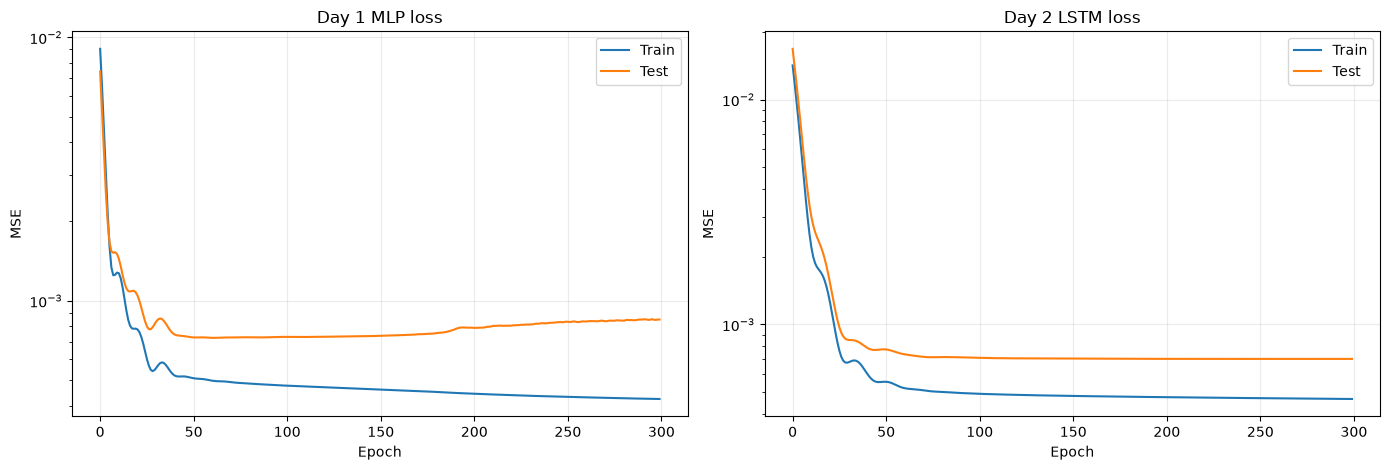

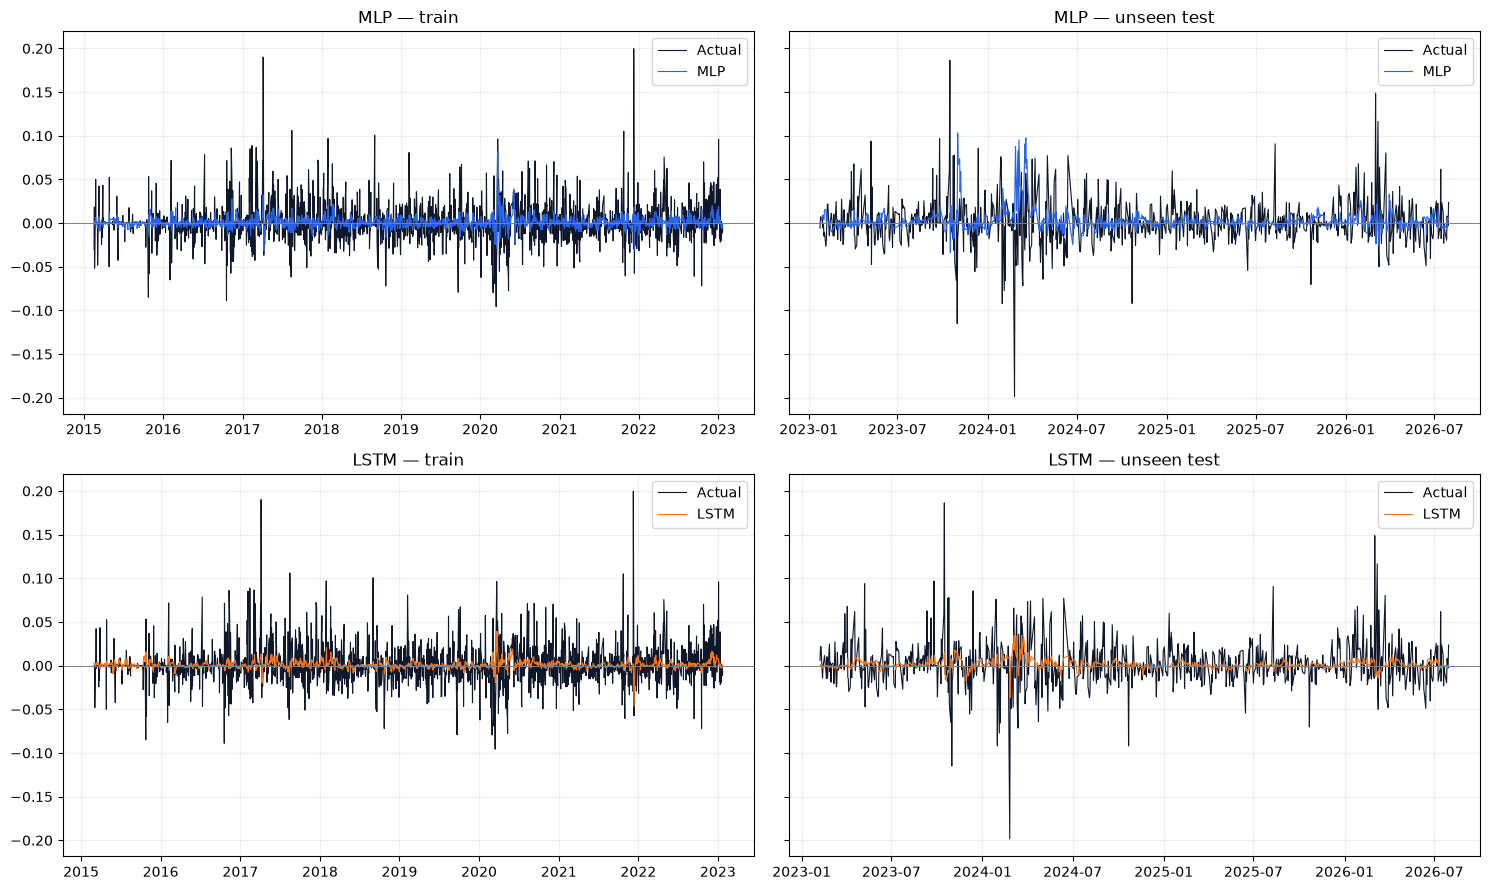

In [51]:
mlp_train_pred = predict(mlp, X_train)
mlp_test_pred = predict(mlp, X_test)
lstm_train_pred = predict(lstm, X_train_seq)
lstm_test_pred = predict(lstm, X_test_seq)
aligned_mlp_pred = mlp_test_pred[SEQ_LEN-1:]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(mlp_history['train'], label='Train')
axes[0].plot(mlp_history['test'], label='Test')
axes[0].set_title('Day 1 MLP loss'); axes[0].set_yscale('log')
axes[1].plot(lstm_history['train'], label='Train')
axes[1].plot(lstm_history['test'], label='Test')
axes[1].set_title('Day 2 LSTM loss'); axes[1].set_yscale('log')
for ax in axes:
    ax.set(xlabel='Epoch', ylabel='MSE'); ax.grid(alpha=.25); ax.legend()
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=True)
axes[0,0].plot(dates_train_raw, y_train_raw, label='Actual', color='#0f172a', lw=.8)
axes[0,0].plot(dates_train_raw, mlp_train_pred, label='MLP', color='#2563eb', lw=.8)
axes[0,0].set_title('MLP — train')
axes[0,1].plot(dates_test_raw, y_test_raw, label='Actual', color='#0f172a', lw=.8)
axes[0,1].plot(dates_test_raw, mlp_test_pred, label='MLP', color='#2563eb', lw=.8)
axes[0,1].set_title('MLP — unseen test')
axes[1,0].plot(dates_train_seq, y_train_seq, label='Actual', color='#0f172a', lw=.8)
axes[1,0].plot(dates_train_seq, lstm_train_pred, label='LSTM', color='#f97316', lw=.8)
axes[1,0].set_title('LSTM — train')
axes[1,1].plot(dates_test_seq, y_test_seq, label='Actual', color='#0f172a', lw=.8)
axes[1,1].plot(dates_test_seq, lstm_test_pred, label='LSTM', color='#f97316', lw=.8)
axes[1,1].set_title('LSTM — unseen test')
for ax in axes.ravel():
    ax.axhline(0, color='gray', lw=.7); ax.grid(alpha=.2); ax.legend()
plt.tight_layout(); plt.show()

## 3b. Predicted price versus actual price

The networks predict a return, not a price directly. To make the forecasts easier to see, we convert each predicted return into a one-day-ahead price:

$$\widehat{P}_{t+1}=P_t(1+\widehat{r}_{t+1})$$

Both models are plotted on the LSTM's date range so the visual comparison uses exactly the same unseen observations.

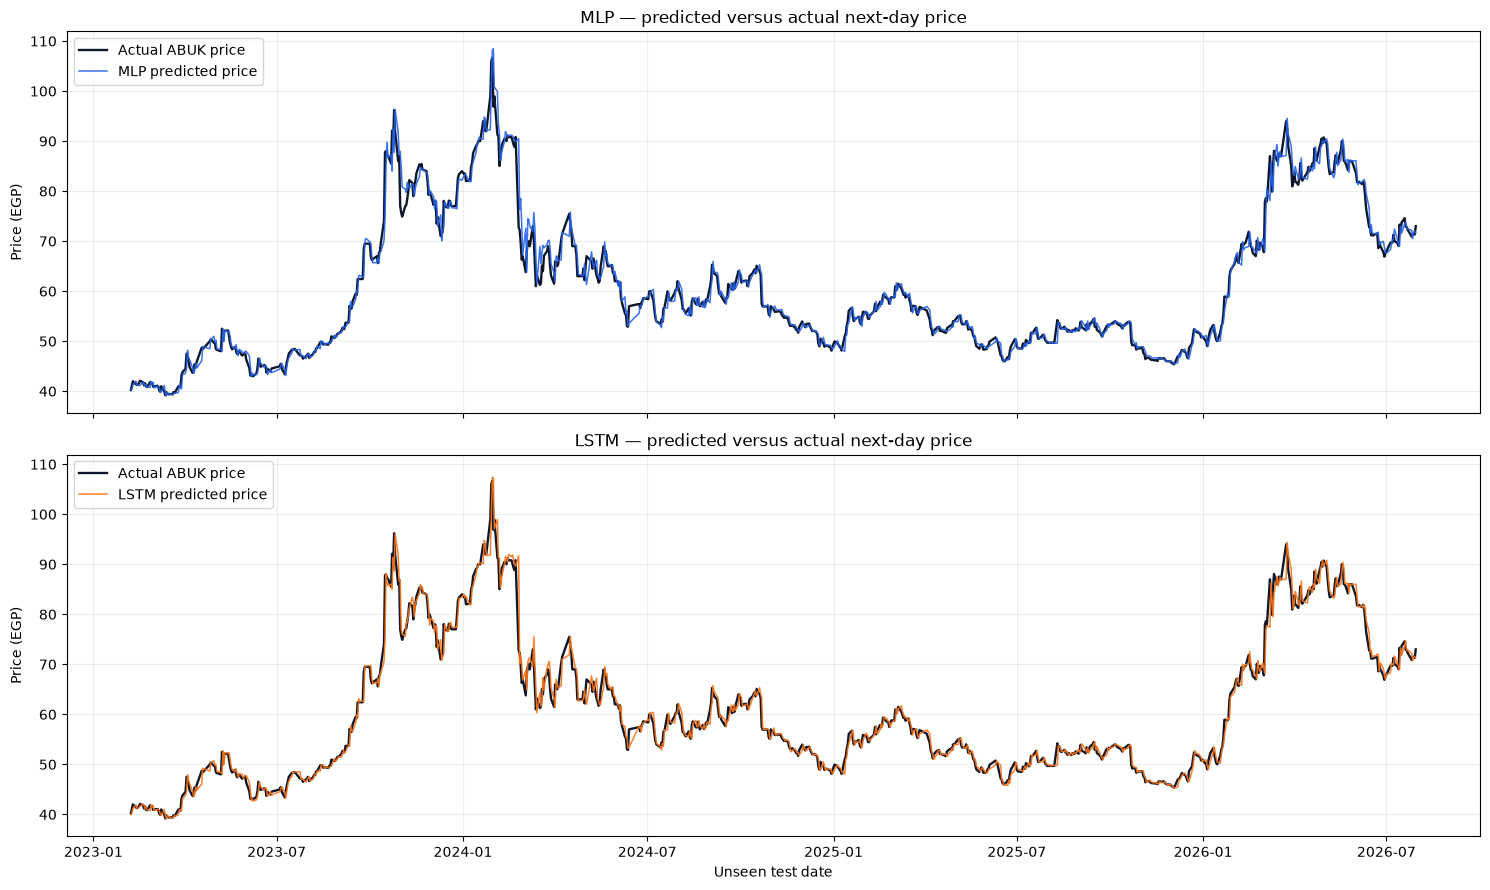

In [52]:
# Align prices and MLP forecasts with the LSTM's sequence-warm-up dates.
test_valid_days = valid_days[cut:]
aligned_days = test_valid_days[SEQ_LEN-1:]
previous_prices = feed.close[aligned_days, 0]
actual_prices = feed.close[aligned_days + 1, 0]
mlp_predicted_prices = previous_prices * (1 + aligned_mlp_pred)
lstm_predicted_prices = previous_prices * (1 + lstm_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, sharey=True)
axes[0].plot(dates_test_seq, actual_prices, label='Actual ABUK price', color='#0f172a', lw=1.7)
axes[0].plot(dates_test_seq, mlp_predicted_prices, label='MLP predicted price', color='#2563eb', lw=1.1, alpha=.9)
axes[0].set_title('MLP — predicted versus actual next-day price')
axes[1].plot(dates_test_seq, actual_prices, label='Actual ABUK price', color='#0f172a', lw=1.7)
axes[1].plot(dates_test_seq, lstm_predicted_prices, label='LSTM predicted price', color='#f97316', lw=1.1, alpha=.9)
axes[1].set_title('LSTM — predicted versus actual next-day price')
for ax in axes:
    ax.set_ylabel('Price (EGP)'); ax.grid(alpha=.22); ax.legend(loc='upper left')
axes[1].set_xlabel('Unseen test date')
plt.tight_layout(); plt.show()

## 3c. ABUK portfolio value from each model

For a direct single-stock trading comparison:

- predicted return above zero → hold ABUK for that day;
- predicted return at or below zero → hold cash;
- start with 1,000 EGP;
- use the same unseen dates for MLP and LSTM;
- ignore transaction costs, slippage, dividends, and whole-share restrictions.

Buy-and-hold is included as a benchmark over the identical period.

,Final value (EGP),Total return,Days invested
MLP signal,"1,920.14",92.01%,59.76%
LSTM signal,"3,504.56",250.46%,61.43%
ABUK buy and hold,"1,825.00",82.50%,100.00%


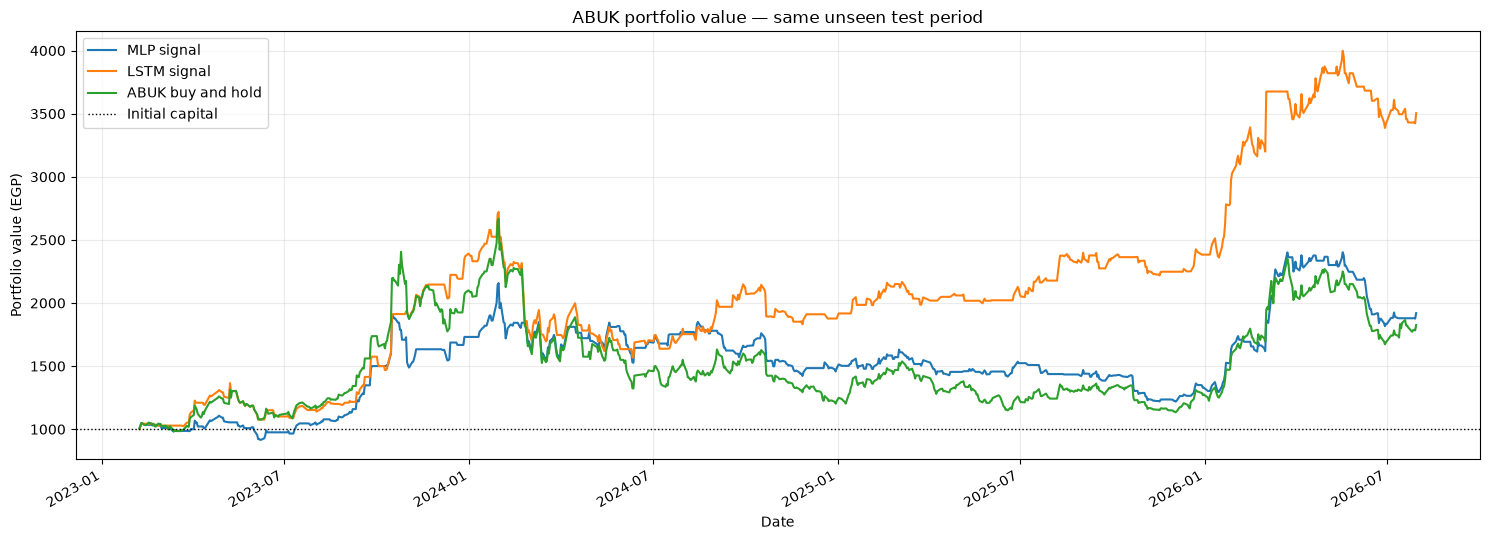

In [53]:
INITIAL_CASH_ABUK = 1_000.0
mlp_position = (aligned_mlp_pred > 0).astype(float)
lstm_position = (lstm_test_pred > 0).astype(float)

mlp_abuk_returns = mlp_position * y_test_seq
lstm_abuk_returns = lstm_position * y_test_seq
buy_hold_abuk_returns = y_test_seq

abuk_portfolios = pd.DataFrame({
    'MLP signal': INITIAL_CASH_ABUK*np.cumprod(1+mlp_abuk_returns),
    'LSTM signal': INITIAL_CASH_ABUK*np.cumprod(1+lstm_abuk_returns),
    'ABUK buy and hold': INITIAL_CASH_ABUK*np.cumprod(1+buy_hold_abuk_returns),
}, index=dates_test_seq)

abuk_summary = pd.DataFrame({
    'Final value (EGP)': abuk_portfolios.iloc[-1],
    'Total return': abuk_portfolios.iloc[-1]/INITIAL_CASH_ABUK-1,
    'Days invested': [mlp_position.mean(), lstm_position.mean(), 1.0],
})
display(abuk_summary.style.format({
    'Final value (EGP)': '{:,.2f}', 'Total return': '{:.2%}', 'Days invested': '{:.2%}'
}))

ax = abuk_portfolios.plot(figsize=(15, 5.5), title='ABUK portfolio value — same unseen test period')
ax.axhline(INITIAL_CASH_ABUK, color='black', ls=':', lw=1, label='Initial capital')
ax.set(xlabel='Date', ylabel='Portfolio value (EGP)')
ax.grid(alpha=.25); ax.legend()
plt.tight_layout(); plt.show()

## 3d. Rule-based comparisons: SMA and TikTok

SMA and TikTok do not forecast a numeric return, so a predicted-price line would be fabricated. Their honest price-view equivalent is the actual ABUK price with the strategy's **invested** and **cash** decisions marked on each decision day.

- **SMA(9,20):** hold ABUK when its 9-day average is above its 20-day average; otherwise hold cash.
- **TikTok five-day loser:** hold ABUK when its compounded return over the latest five trading days is negative; otherwise hold cash. This is the repository's long-only mean-reversion interpretation of “buy last week's loser.”

Both rules use only information available through day $t$ and earn only day $t+1$'s return.

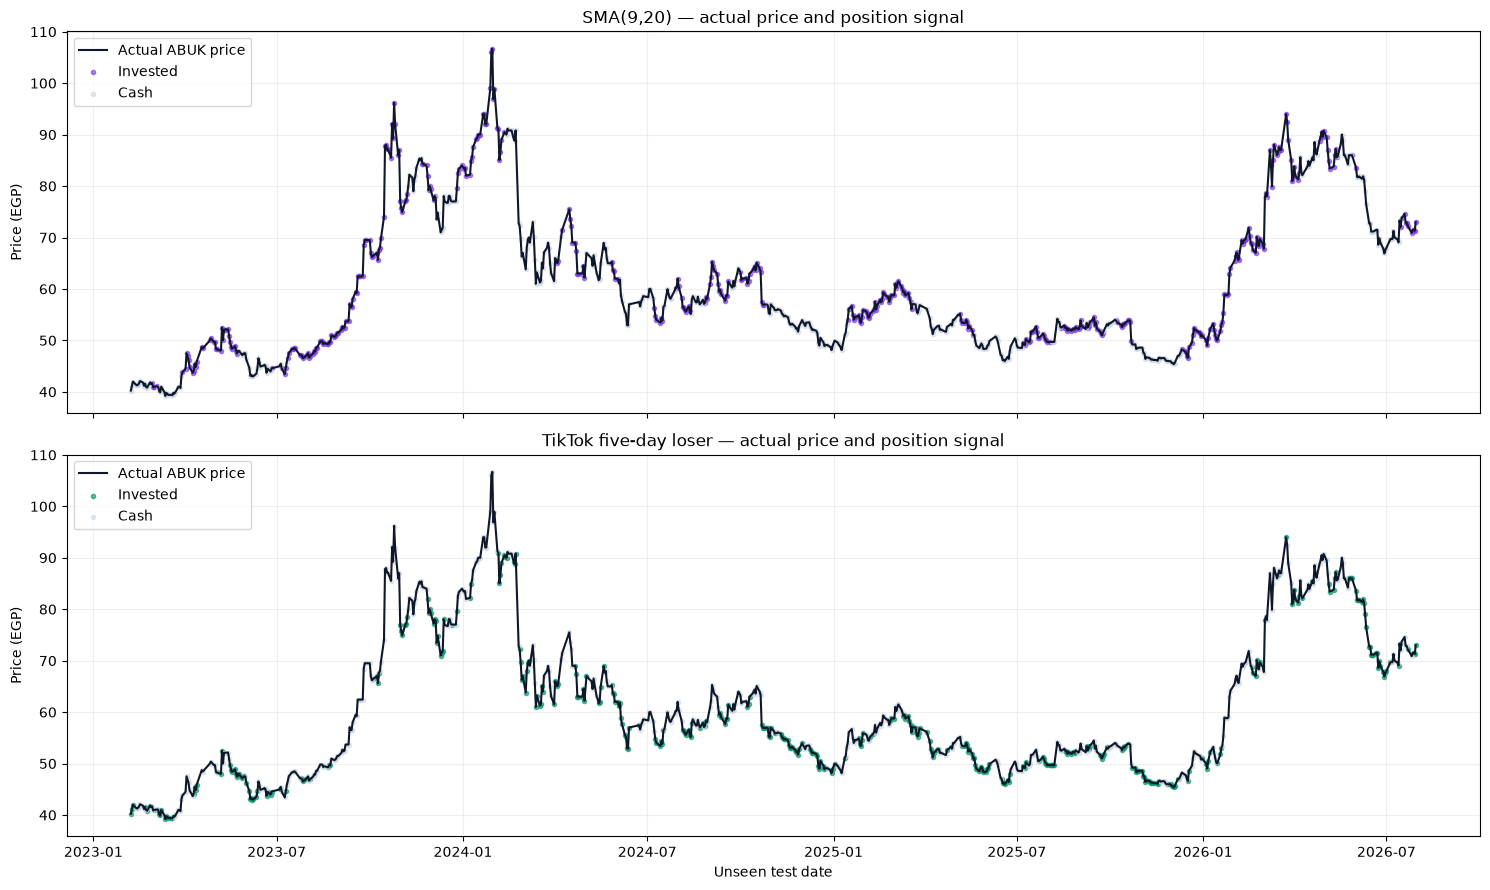

In [54]:
sma_signal, tiktok_signal = [], []
for feature_day in aligned_days:
    history_price = feed.close[:feature_day+1, 0]
    fast_sma = history_price[-9:].mean()
    slow_sma = history_price[-20:].mean()
    sma_signal.append(float(fast_sma > slow_sma))

    recent_returns = feed.returns[feature_day-4:feature_day+1, 0]
    five_day_return = np.prod(1+recent_returns)-1
    tiktok_signal.append(float(five_day_return < 0))

sma_signal = np.asarray(sma_signal)
tiktok_signal = np.asarray(tiktok_signal)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, sharey=True)
for ax, signal, title, color in [
    (axes[0], sma_signal, 'SMA(9,20) — actual price and position signal', '#7c3aed'),
    (axes[1], tiktok_signal, 'TikTok five-day loser — actual price and position signal', '#059669'),
]:
    ax.plot(dates_test_seq, actual_prices, color='#0f172a', lw=1.5, label='Actual ABUK price')
    invested = signal.astype(bool)
    ax.scatter(dates_test_seq[invested], actual_prices[invested], s=9, color=color, alpha=.65, label='Invested')
    ax.scatter(dates_test_seq[~invested], actual_prices[~invested], s=9, color='#cbd5e1', alpha=.55, label='Cash')
    ax.set_title(title); ax.set_ylabel('Price (EGP)'); ax.grid(alpha=.2); ax.legend(loc='upper left')
axes[1].set_xlabel('Unseen test date')
plt.tight_layout(); plt.show()

,Final value (EGP),Total return,Annualized return,Annualized volatility,Sharpe (rf=0),Max drawdown,Days invested
MLP signal,"1,920.14",92.01%,21.62%,33.50%,0.65,-43.51%,59.76%
LSTM signal,"3,504.56",250.46%,45.68%,34.29%,1.33,-42.43%,61.43%
"SMA(9,20)","1,800.76",80.08%,19.30%,31.07%,0.62,-48.23%,53.33%
TikTok 5-day loser,980.98,-1.90%,-0.57%,26.67%,-0.02,-40.43%,47.98%
ABUK buy and hold,"1,825.00",82.50%,19.78%,41.72%,0.47,-57.48%,100.00%


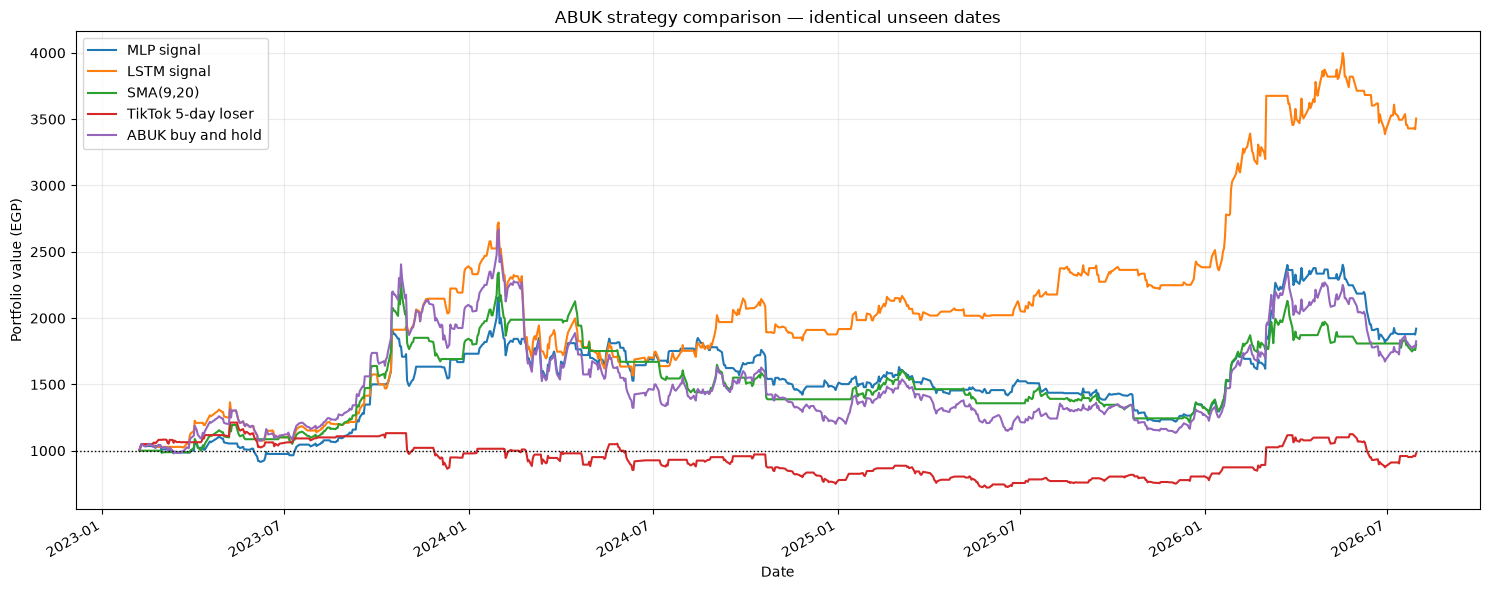

In [55]:
sma_abuk_returns = sma_signal*y_test_seq
tiktok_abuk_returns = tiktok_signal*y_test_seq

all_abuk_portfolios = pd.DataFrame({
    'MLP signal': INITIAL_CASH_ABUK*np.cumprod(1+mlp_abuk_returns),
    'LSTM signal': INITIAL_CASH_ABUK*np.cumprod(1+lstm_abuk_returns),
    'SMA(9,20)': INITIAL_CASH_ABUK*np.cumprod(1+sma_abuk_returns),
    'TikTok 5-day loser': INITIAL_CASH_ABUK*np.cumprod(1+tiktok_abuk_returns),
    'ABUK buy and hold': INITIAL_CASH_ABUK*np.cumprod(1+buy_hold_abuk_returns),
}, index=dates_test_seq)

def single_asset_metrics(daily_returns, signal):
    curve = INITIAL_CASH_ABUK*np.cumprod(1+daily_returns)
    peak = np.maximum.accumulate(curve)
    drawdown = curve/peak-1
    ann_return = np.prod(1+daily_returns)**(252/len(daily_returns))-1
    ann_vol = np.std(daily_returns, ddof=1)*np.sqrt(252)
    return {
        'Final value (EGP)': curve[-1],
        'Total return': curve[-1]/INITIAL_CASH_ABUK-1,
        'Annualized return': ann_return,
        'Annualized volatility': ann_vol,
        'Sharpe (rf=0)': ann_return/ann_vol if ann_vol else np.nan,
        'Max drawdown': drawdown.min(),
        'Days invested': np.mean(signal),
    }

all_abuk_summary = pd.DataFrame({
    'MLP signal': single_asset_metrics(mlp_abuk_returns, mlp_position),
    'LSTM signal': single_asset_metrics(lstm_abuk_returns, lstm_position),
    'SMA(9,20)': single_asset_metrics(sma_abuk_returns, sma_signal),
    'TikTok 5-day loser': single_asset_metrics(tiktok_abuk_returns, tiktok_signal),
    'ABUK buy and hold': single_asset_metrics(buy_hold_abuk_returns, np.ones_like(y_test_seq)),
}).T
display(all_abuk_summary.style.format({
    'Final value (EGP)':'{:,.2f}', 'Total return':'{:.2%}', 'Annualized return':'{:.2%}',
    'Annualized volatility':'{:.2%}', 'Sharpe (rf=0)':'{:.2f}',
    'Max drawdown':'{:.2%}', 'Days invested':'{:.2%}'
}))

ax = all_abuk_portfolios.plot(figsize=(15, 6), title='ABUK strategy comparison — identical unseen dates')
ax.axhline(INITIAL_CASH_ABUK, color='black', ls=':', lw=1)
ax.set(xlabel='Date', ylabel='Portfolio value (EGP)'); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 4. Direct ABUK comparison

MSE and MAE measure numeric forecast error. Direction accuracy asks whether the predicted sign matches the actual sign. Correlation asks whether forecasts and outcomes move together. The zero-return baseline predicts exactly 0 every day; a complex model should beat it before we call its return forecast useful.

In [56]:
def metric_row(name, actual, pred):
    has_varying_predictions = np.std(pred) > 0
    return {
        'Model': name,
        'Test MSE': np.mean((actual-pred)**2),
        'Test MAE': np.mean(np.abs(actual-pred)),
        # Sign accuracy/correlation are undefined for an always-zero forecast.
        'Direction accuracy': np.mean(np.sign(actual) == np.sign(pred)) if has_varying_predictions else np.nan,
        'Correlation': np.corrcoef(actual, pred)[0,1] if has_varying_predictions else np.nan,
    }

comparison = pd.DataFrame([
    metric_row('MLP', y_test_seq, aligned_mlp_pred),
    metric_row('LSTM', y_test_seq, lstm_test_pred),
    metric_row('Zero-return baseline', y_test_seq, np.zeros_like(y_test_seq)),
]).set_index('Model')
display(comparison.style.format({
    'Test MSE':'{:.8f}', 'Test MAE':'{:.4%}',
    'Direction accuracy':'{:.2%}', 'Correlation':'{:.3f}'
}))

winner = comparison.loc[['MLP','LSTM'], 'Test MSE'].idxmin()
ratio = comparison.loc['MLP','Test MSE'] / comparison.loc['LSTM','Test MSE']
print(f'Lower neural-network test MSE: {winner}')
print(f'MLP MSE / LSTM MSE: {ratio:.3f} (>1 means LSTM is better)')
print(f"LSTM beats zero-return baseline: {comparison.loc['LSTM','Test MSE'] < comparison.loc['Zero-return baseline','Test MSE']}")

,Test MSE,Test MAE,Direction accuracy,Correlation
Model,,,,
MLP,0.00085351,1.9191%,47.98%,-0.000
LSTM,0.00070315,1.7612%,50.95%,0.053
Zero-return baseline,0.00069089,1.7173%,nan%,nan


Lower neural-network test MSE: LSTM
MLP MSE / LSTM MSE: 1.214 (>1 means LSTM is better)
LSTM beats zero-return baseline: False


## 4b. Transaction-cost sensitivity

Every position change creates turnover. For this single-stock experiment, moving from cash to ABUK or ABUK to cash is one unit of turnover. We subtract commission multiplied by turnover from that day's portfolio return and compare three rates: 0%, 0.1%, and 0.5%.

This simplified model applies commission to portfolio value rather than simulating whole shares and bid–ask execution, but it makes high-turnover strategies pay for frequent switching.

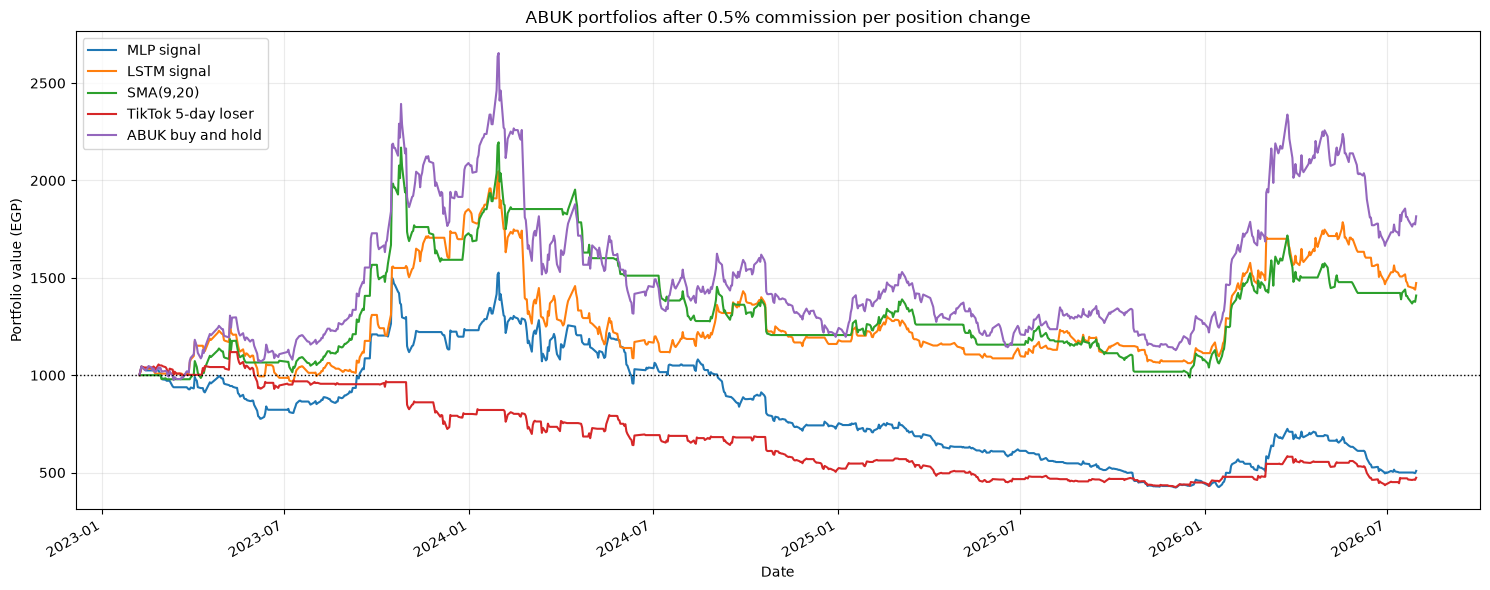

In [57]:
gross_returns = {
    'MLP signal': mlp_abuk_returns,
    'LSTM signal': lstm_abuk_returns,
    'SMA(9,20)': sma_abuk_returns,
    'TikTok 5-day loser': tiktok_abuk_returns,
    'ABUK buy and hold': buy_hold_abuk_returns,
}
positions = {
    'MLP signal': mlp_position,
    'LSTM signal': lstm_position,
    'SMA(9,20)': sma_signal,
    'TikTok 5-day loser': tiktok_signal,
    'ABUK buy and hold': np.ones_like(y_test_seq),
}

def returns_after_commission(gross, position, commission):
    prior = np.r_[0.0, position[:-1]]
    turnover = np.abs(position-prior)
    return gross-commission*turnover, turnover

cost_rows = []
cost_curves = {}
for rate in [0.0, 0.001, 0.005]:
    for name in gross_returns:
        net, turnover = returns_after_commission(gross_returns[name], positions[name], rate)
        curve = INITIAL_CASH_ABUK*np.cumprod(1+net)
        cost_rows.append({
            'Commission': f'{rate:.1%}', 'Strategy': name,
            'Final value (EGP)': curve[-1], 'Total return': curve[-1]/INITIAL_CASH_ABUK-1,
            'Position changes': int(np.count_nonzero(turnover)), 'Total turnover': turnover.sum(),
        })
        if rate == .005:
            cost_curves[name] = curve

cost_results = pd.DataFrame(cost_rows).set_index(['Commission','Strategy'])
display(cost_results.style.format({
    'Final value (EGP)':'{:,.2f}', 'Total return':'{:.2%}', 'Total turnover':'{:.0f}'
}))

ax = pd.DataFrame(cost_curves, index=dates_test_seq).plot(
    figsize=(15,6), title='ABUK portfolios after 0.5% commission per position change'
)
ax.axhline(INITIAL_CASH_ABUK, color='black', ls=':', lw=1)
ax.set(xlabel='Date', ylabel='Portfolio value (EGP)'); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 4c. Stability across five random seeds

Neural-network initialization and optimizer order can change the fitted solution. We retrain each architecture with five seeds while keeping the data, split, architecture, epochs, and learning rate fixed.

The table reports every run; the summary reports the mean and standard deviation. A strategy is more credible when its conclusion does not depend on one lucky initialization.

In [58]:
seed_rows = []
for seed in [0, 1, 2, 3, 4]:
    torch.manual_seed(seed)
    seed_mlp = ReturnMLP(len(FEATURE_NAMES))
    train(seed_mlp, X_train, y_train_raw, X_test, y_test_raw, epochs=200)
    seed_mlp_pred = predict(seed_mlp, X_test)[SEQ_LEN-1:]

    torch.manual_seed(seed)
    seed_lstm = ReturnLSTM(len(FEATURE_NAMES), hidden=32)
    train(seed_lstm, X_train_seq, y_train_seq, X_test_seq, y_test_seq, epochs=200)
    seed_lstm_pred = predict(seed_lstm, X_test_seq)

    for name, pred in [('MLP', seed_mlp_pred), ('LSTM', seed_lstm_pred)]:
        daily = (pred > 0).astype(float)*y_test_seq
        curve = INITIAL_CASH_ABUK*np.cumprod(1+daily)
        seed_rows.append({
            'Seed': seed, 'Model': name,
            'Test MSE': np.mean((y_test_seq-pred)**2),
            'Direction accuracy': np.mean(np.sign(y_test_seq)==np.sign(pred)),
            'Final value (EGP)': curve[-1],
            'Portfolio return': curve[-1]/INITIAL_CASH_ABUK-1,
        })

seed_results = pd.DataFrame(seed_rows).set_index(['Model','Seed']).sort_index()
display(seed_results.style.format({
    'Test MSE':'{:.8f}', 'Direction accuracy':'{:.2%}',
    'Final value (EGP)':'{:,.2f}', 'Portfolio return':'{:.2%}'
}))

seed_summary = seed_results.reset_index().groupby('Model').agg({
    'Test MSE':['mean','std','min','max'],
    'Direction accuracy':['mean','std'],
    'Final value (EGP)':['mean','std','min','max'],
    'Portfolio return':['mean','std'],
})
display(seed_summary)

Test MSE                               Direction accuracy            \
           mean       std       min       max               mean       std   
Model                                                                        
LSTM   0.000728  0.000015  0.000717  0.000754           0.474524  0.009657   
MLP    0.000773  0.000046  0.000740  0.000849           0.470238  0.011262   

      Final value (EGP)                                        \
                   mean         std          min          max   
Model                                                           
LSTM        2005.340923  509.080653  1306.223394  2735.404966   
MLP         1330.806207  145.277748  1101.849090  1503.676821   

      Portfolio return            
                  mean       std  
Model                             
LSTM          1.005341  0.509081  
MLP           0.330806  0.145278

## 4d. Expanding-window walk-forward evaluation

A single fixed model can become stale. In this evaluation we:

1. begin with the original 70% training history;
2. fit scaling and both networks using only information available at that point;
3. predict the next 126 trading days;
4. expand training history to include that completed block;
5. retrain and repeat.

Every prediction is therefore generated by a freshly fitted model that has never seen its target day. The seed is held fixed so this section isolates the effect of walk-forward retraining; seed uncertainty was measured separately above.

,Train through,Predict through,Test days,MLP MSE,LSTM MSE
0,2023-01-23,2023-08-08,126,0.00049198,0.00046242
1,2023-08-08,2024-02-07,126,0.00128933,0.00122596
2,2024-02-07,2024-08-26,126,0.00130196,0.00131101
3,2024-08-26,2025-02-24,126,0.00038551,0.00036846
4,2025-02-24,2025-09-10,126,0.00031315,0.00029154
5,2025-09-10,2026-03-11,126,0.00069718,0.00067898
6,2026-03-11,2026-07-30,93,0.00053454,0.00051770


,Test MSE,Direction accuracy,Final value (EGP),Total return
Model,,,,
Walk-forward MLP,0.00072330,48.29%,"1,250.30",25.03%
Walk-forward LSTM,0.00070057,50.65%,"3,497.28",249.73%


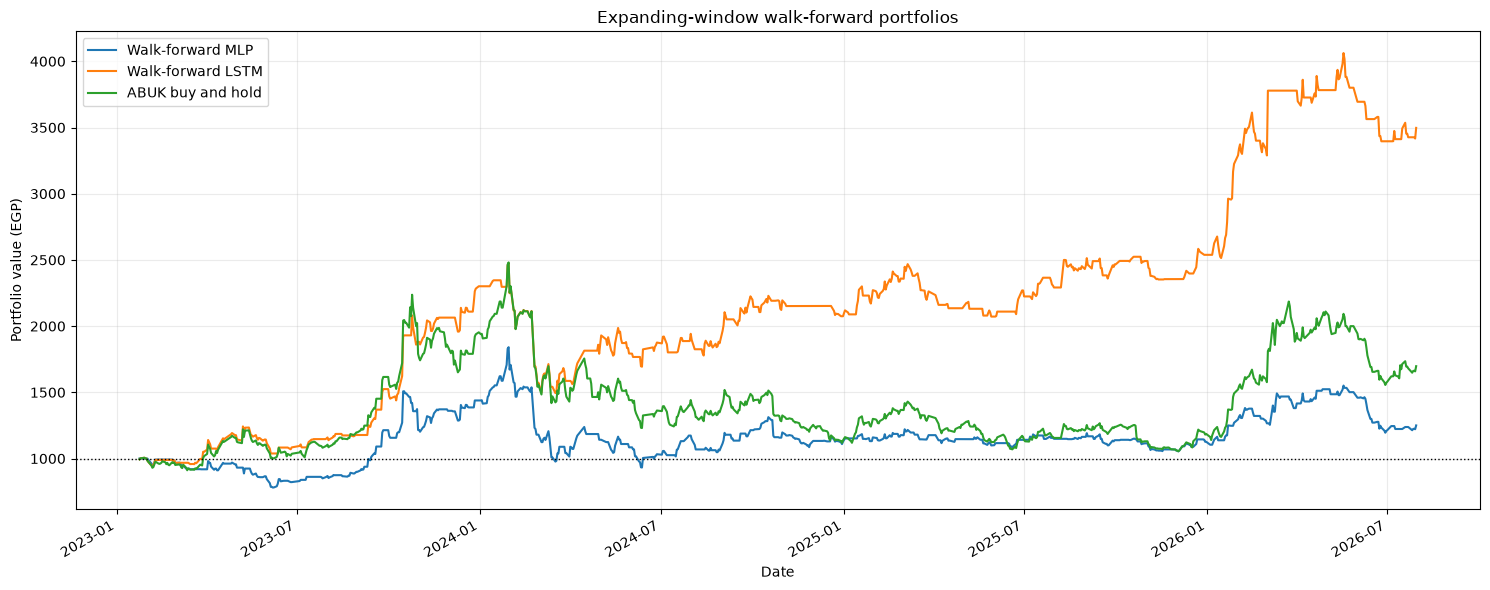

In [59]:
WF_STEP = 126
wf_dates, wf_actual, wf_mlp_pred, wf_lstm_pred = [], [], [], []
fold_rows = []

for fold_start in range(cut, len(X), WF_STEP):
    fold_end = min(fold_start+WF_STEP, len(X))
    Xtr_raw_fold, ytr_fold = X[:fold_start], y[:fold_start]
    fold_mu = Xtr_raw_fold.mean(axis=0)
    fold_sigma = Xtr_raw_fold.std(axis=0); fold_sigma[fold_sigma == 0] = 1
    Xtr_fold = ((Xtr_raw_fold-fold_mu)/fold_sigma).astype('float32')
    Xval_fold = ((X[fold_start:fold_end]-fold_mu)/fold_sigma).astype('float32')
    yval_fold = y[fold_start:fold_end]

    # The helper records a monitoring curve, but no early stopping or model
    # selection uses it. Fit on every row available at this fold.
    torch.manual_seed(SEED)
    wf_mlp = ReturnMLP(len(FEATURE_NAMES))
    train(wf_mlp, Xtr_fold, ytr_fold,
          Xtr_fold[-126:], ytr_fold[-126:], epochs=120)
    fold_mlp_pred = predict(wf_mlp, Xval_fold)

    Xtr_seq_fold, ytr_seq_fold, _ = make_sequences(
        Xtr_fold, ytr_fold, target_dates[:fold_start]
    )
    torch.manual_seed(SEED)
    wf_lstm = ReturnLSTM(len(FEATURE_NAMES), hidden=32)
    train(wf_lstm, Xtr_seq_fold, ytr_seq_fold,
          Xtr_seq_fold[-126:], ytr_seq_fold[-126:], epochs=120)

    # Include the last nine training feature rows as context, but predict labels
    # only inside the new forward block.
    context_start = fold_start-SEQ_LEN+1
    context = ((X[context_start:fold_end]-fold_mu)/fold_sigma).astype('float32')
    fold_sequences = np.asarray([
        context[i:i+SEQ_LEN] for i in range(fold_end-fold_start)
    ], dtype='float32')
    fold_lstm_pred = predict(wf_lstm, fold_sequences)

    actual_fold = y[fold_start:fold_end]
    dates_fold = target_dates[fold_start:fold_end]
    wf_dates.extend(dates_fold); wf_actual.extend(actual_fold)
    wf_mlp_pred.extend(fold_mlp_pred); wf_lstm_pred.extend(fold_lstm_pred)
    fold_rows.append({
        'Train through': target_dates[fold_start-1].date(),
        'Predict through': target_dates[fold_end-1].date(),
        'Test days': len(actual_fold),
        'MLP MSE': np.mean((actual_fold-fold_mlp_pred)**2),
        'LSTM MSE': np.mean((actual_fold-fold_lstm_pred)**2),
    })

wf_dates = pd.DatetimeIndex(wf_dates)
wf_actual = np.asarray(wf_actual); wf_mlp_pred = np.asarray(wf_mlp_pred); wf_lstm_pred = np.asarray(wf_lstm_pred)
display(pd.DataFrame(fold_rows).style.format({'MLP MSE':'{:.8f}','LSTM MSE':'{:.8f}'}))

wf_rows, wf_curves = [], {}
for name, pred in [('Walk-forward MLP', wf_mlp_pred), ('Walk-forward LSTM', wf_lstm_pred)]:
    daily = (pred > 0).astype(float)*wf_actual
    curve = INITIAL_CASH_ABUK*np.cumprod(1+daily)
    wf_curves[name] = curve
    wf_rows.append({
        'Model': name, 'Test MSE': np.mean((wf_actual-pred)**2),
        'Direction accuracy': np.mean(np.sign(wf_actual)==np.sign(pred)),
        'Final value (EGP)': curve[-1], 'Total return': curve[-1]/INITIAL_CASH_ABUK-1,
    })
wf_curves['ABUK buy and hold'] = INITIAL_CASH_ABUK*np.cumprod(1+wf_actual)
wf_results = pd.DataFrame(wf_rows).set_index('Model')
display(wf_results.style.format({
    'Test MSE':'{:.8f}', 'Direction accuracy':'{:.2%}',
    'Final value (EGP)':'{:,.2f}', 'Total return':'{:.2%}'
}))

ax = pd.DataFrame(wf_curves, index=wf_dates).plot(figsize=(15,6), title='Expanding-window walk-forward portfolios')
ax.axhline(INITIAL_CASH_ABUK, color='black', ls=':', lw=1)
ax.set(xlabel='Date', ylabel='Portfolio value (EGP)'); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 5. Apply both model types across the full universe

For a portfolio model, we train one pooled MLP and one pooled LSTM on all stocks, while keeping the split by **calendar date**. This lets the networks learn one shared mapping from technical features to next-day return. Feature scaling is again fitted only on training rows.

Each test day:

- predict every stock's next-day return;
- keep only positive forecasts;
- hold the three highest forecasts at equal weights;
- otherwise hold cash.

The benchmark equally weights every available stock. Results ignore fees, slippage, and whole-share constraints.

In [60]:
universe = DataFeed.from_dir(DATA_DIR)
split_day = int(universe.n_days * 0.70)

train_rows, train_targets = [], []
test_by_asset = {}
for a, symbol in enumerate(universe.symbols):
    Xa = feature_columns(universe, a)
    ya = np.full(universe.n_days, np.nan); ya[:-1] = universe.returns[1:, a]
    valid_a = ~np.isnan(Xa).any(axis=1) & ~np.isnan(ya)
    train_mask = valid_a & (np.arange(universe.n_days) < split_day)
    train_rows.append(Xa[train_mask]); train_targets.append(ya[train_mask])
    test_by_asset[a] = (Xa, ya, valid_a)

X_pool_raw = np.vstack(train_rows).astype('float32')
y_pool = np.concatenate(train_targets).astype('float32')
pool_mu, pool_sigma = X_pool_raw.mean(axis=0), X_pool_raw.std(axis=0)
pool_sigma[pool_sigma == 0] = 1
X_pool = ((X_pool_raw-pool_mu)/pool_sigma).astype('float32')

# Pooled MLP rows. The final 20% of the training-period pool is used only to watch loss.
pool_cut = int(len(X_pool)*.8)
torch.manual_seed(SEED)
pool_mlp = ReturnMLP(len(FEATURE_NAMES))
pool_mlp_hist = train(pool_mlp, X_pool[:pool_cut], y_pool[:pool_cut], X_pool[pool_cut:], y_pool[pool_cut:], epochs=120)

# Pooled LSTM sequences are built per stock and never cross stock boundaries.
seqs, seq_targets = [], []
for a in range(universe.n_assets):
    Xa, ya, valid_a = test_by_asset[a]
    mask = valid_a & (np.arange(universe.n_days) < split_day)
    Xpart = ((Xa[mask]-pool_mu)/pool_sigma).astype('float32')
    ypart = ya[mask].astype('float32')
    for end in range(SEQ_LEN-1, len(Xpart)):
        seqs.append(Xpart[end-SEQ_LEN+1:end+1]); seq_targets.append(ypart[end])
X_pool_seq = np.asarray(seqs, dtype='float32')
y_pool_seq = np.asarray(seq_targets, dtype='float32')
seq_cut = int(len(X_pool_seq)*.8)
torch.manual_seed(SEED)
pool_lstm = ReturnLSTM(len(FEATURE_NAMES), hidden=32)
pool_lstm_hist = train(pool_lstm, X_pool_seq[:seq_cut], y_pool_seq[:seq_cut], X_pool_seq[seq_cut:], y_pool_seq[seq_cut:], epochs=120)

print(f'Universe: {universe.n_assets} stocks, {universe.n_days:,} common dates')
print(f'Portfolio test starts: {universe.dates[split_day + SEQ_LEN].date()}')

Universe: 34 stocks, 1,159 common dates
Portfolio test starts: 2025-03-06


,Total return,Annualized return,Annualized volatility,Sharpe (rf=0),Positive days
Pooled MLP top-3,171.18%,110.39%,25.09%,4.40,56.80%
Pooled LSTM top-3,25.52%,18.47%,28.32%,0.65,50.59%
Equal-weight universe,56.82%,39.86%,16.10%,2.48,58.88%


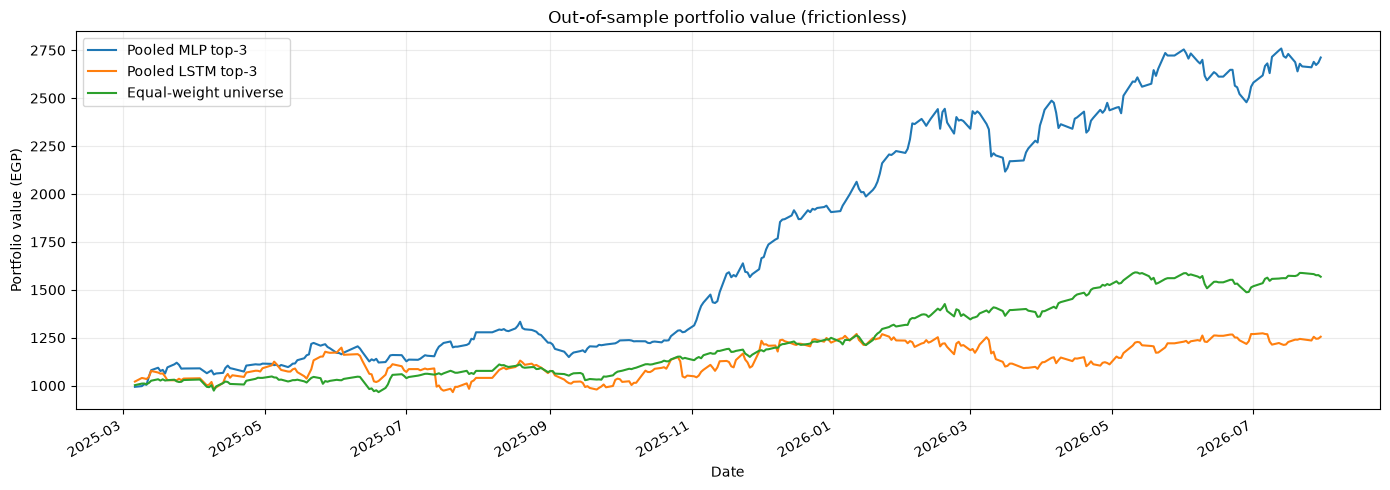

In [61]:
def top_k_weights(predictions, k=3):
    weights = np.zeros_like(predictions, dtype=float)
    positive = np.flatnonzero(predictions > 0)
    if len(positive):
        chosen = positive[np.argsort(predictions[positive])[-min(k, len(positive)):]]
        weights[chosen] = 1/len(chosen)
    return weights

portfolio_days, mlp_daily, lstm_daily, benchmark_daily = [], [], [], []
start = split_day + SEQ_LEN
for target_day in range(start, universe.n_days):
    feature_day = target_day - 1
    current = np.vstack([feature_columns(universe, a)[feature_day] for a in range(universe.n_assets)])
    window = np.stack([
        feature_columns(universe, a)[feature_day-SEQ_LEN+1:feature_day+1]
        for a in range(universe.n_assets)
    ])
    if np.isnan(current).any() or np.isnan(window).any():
        continue
    current_scaled = ((current-pool_mu)/pool_sigma).astype('float32')
    window_scaled = ((window-pool_mu)/pool_sigma).astype('float32')
    p_mlp = predict(pool_mlp, current_scaled)
    p_lstm = predict(pool_lstm, window_scaled)
    realized = universe.returns[target_day]
    mlp_daily.append(top_k_weights(p_mlp) @ realized)
    lstm_daily.append(top_k_weights(p_lstm) @ realized)
    benchmark_daily.append(realized.mean())
    portfolio_days.append(universe.dates[target_day])

portfolio_days = pd.DatetimeIndex(portfolio_days)
mlp_daily = np.asarray(mlp_daily); lstm_daily = np.asarray(lstm_daily)
benchmark_daily = np.asarray(benchmark_daily)

INITIAL_CASH = 1_000.0
curves = pd.DataFrame({
    'Pooled MLP top-3': INITIAL_CASH*np.cumprod(1+mlp_daily),
    'Pooled LSTM top-3': INITIAL_CASH*np.cumprod(1+lstm_daily),
    'Equal-weight universe': INITIAL_CASH*np.cumprod(1+benchmark_daily),
}, index=portfolio_days)

def strategy_metrics(daily):
    ann_return = np.prod(1+daily)**(252/len(daily))-1
    ann_vol = np.std(daily, ddof=1)*np.sqrt(252)
    return {
        'Total return': np.prod(1+daily)-1,
        'Annualized return': ann_return,
        'Annualized volatility': ann_vol,
        'Sharpe (rf=0)': ann_return/ann_vol if ann_vol else np.nan,
        'Positive days': np.mean(daily > 0),
    }

portfolio_results = pd.DataFrame({
    'Pooled MLP top-3': strategy_metrics(mlp_daily),
    'Pooled LSTM top-3': strategy_metrics(lstm_daily),
    'Equal-weight universe': strategy_metrics(benchmark_daily),
}).T
display(portfolio_results.style.format({
    'Total return':'{:.2%}', 'Annualized return':'{:.2%}',
    'Annualized volatility':'{:.2%}', 'Sharpe (rf=0)':'{:.2f}', 'Positive days':'{:.2%}'
}))

ax = curves.plot(figsize=(14,5), title='Out-of-sample portfolio value (frictionless)')
ax.set(xlabel='Date', ylabel='Portfolio value (EGP)'); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 6. How to interpret the outcome

- The sine-wave lesson is only that memory helps when recent history contains a stable sequential pattern.
- ABUK daily returns are noisy and non-stationary. An LSTM has more sequence-handling capacity, but capacity is not evidence that useful information exists.
- A model can have a lower MSE yet produce a worse portfolio, because ranking and sign matter more to the trading rule than tiny numeric-error improvements.
- The portfolio backtest is a first bridge from signal to allocation, not a production strategy. A serious claim needs repeated seeds, walk-forward retraining, trading costs, and an untouched validation period.